### Part 5

## Cleaning the Data 

In [13]:
import pandas as pd
import re 
import requests
import matplotlib.pyplot as plt

df= pd.read_csv('kdramas_2023.csv')
print(df.shape)
df.head()


df["start"] = pd.to_datetime(df['Aired'].str.split(' - ').str[0])
df["end"] = pd.to_datetime(df['Aired'].str.split(' - ').str[-1])

df["run"] = (df["end"]-df["start"]).dt.days

df[["Title_English", "Popularity", "Watchers", "start", "end", "run"]].head()


(213, 18)


,Title_English,Popularity,Watchers,start,end,run
0,High Cookie (2023),1638,15709,2023-10-23,2023-11-23,31
1,Strangers Again (2023),1515,17025,2023-01-18,2023-02-23,36
2,Hello! This Is Starbucks (2023),99999,105,2023-06-20,2023-07-27,37
3,Adult Kids (2023),9473,1250,2023-06-19,2023-08-07,49
4,My Demon (2023),40,165957,2023-11-24,2024-01-20,57


### selecting shows 


In [7]:
top = df.sort_values("Popularity").head(20)
print(top)

     Unnamed: 0  Year                    Title_English  Episodes  Popularity  \
21           21  2023      Twinkling Watermelon (2023)        16          18   
4             4  2023                  My Demon (2023)        16          40   
34           34  2023             King the Land (2023)        16          42   
50           50  2023          The Glory Part 2 (2023)         8          72   
62           62  2023                    Moving (2023)        20          85   
129         129  2023              Death's Game (2023)         4         107   
193         193  2023      Welcome to Samdal-ri (2023)        16         117   
144         144  2023               Bloodhounds (2023)         8         124   
92           92  2023   See You in My 19th Life (2023)        12         125   
65           65  2023         Destined with You (2023)        16         146   
155         155  2023       The Good Bad Mother (2023)        14         150   
121         121  2023            My Love

## and now I scrape? 

In [ ]:
wiki=["The Glory (TV series)", "Moving (South Korean TV series)", "My Demon",
    "King the Land", "Gyeongseong Creature", "Twinkling Watermelon", 
    "Death's Game", "Crash Course in Romance", "Welcome to Samdal-ri", 
    "Celebrity (South Korean TV series)", "A Time Called You", 
    "Perfect Marriage Revenge", "See You in My 19th Life", 
    "The Good Bad Mother", "My Lovely Liar", "Doona!", 
    "Love to Hate You (TV series)", "Daily Dose of Sunshine", 
    "Destined with You", ]

headers = {"User-Agent": "CS315"}
all_shows={}

for title in wiki:
    url = ("https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/"
           + title.replace(" ", "_") + "/daily/20220601/20240601")
    respone = requests.get(url, headers=headers)

    if respone.status_code != 200:
        print("problem!")
        continue 

    show = pd.DataFrame(respone.json()["items"])
    show["date"] = pd.to_datetime(show["timestamp"], format="%Y%m%d%H")
    all_shows[title]= show.set_index("date")["views"]



pageviews = pd.DataFrame(all_shows)
pageviews.to_csv("pageviews.csv")



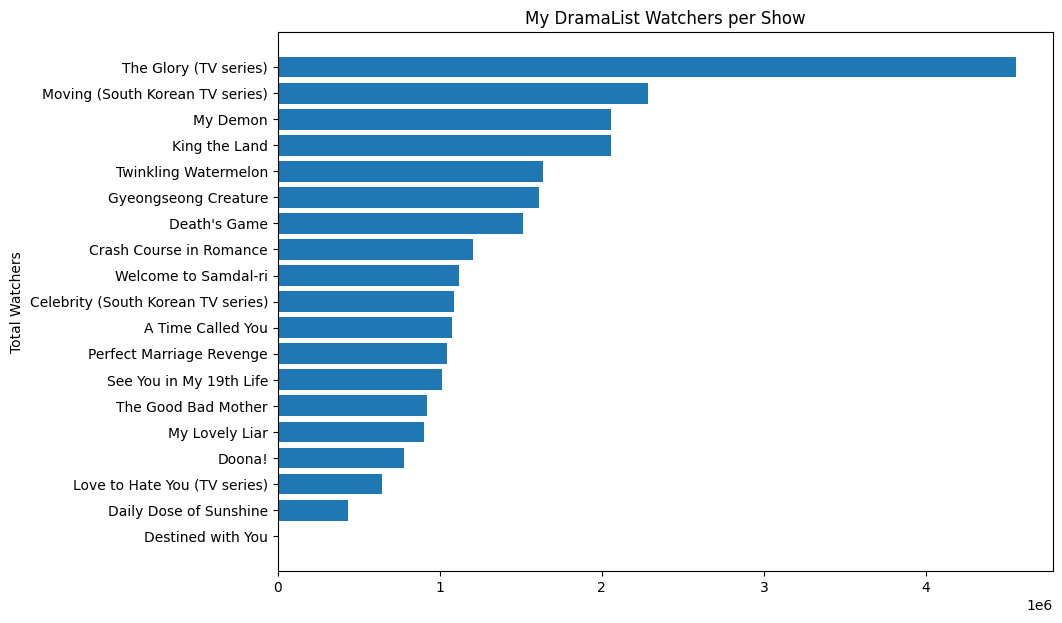

In [21]:
total = pageviews.sum().sort_values()
#bar=top.sort_values("Watchers")


plt.figure(figsize=(10,7))
plt.barh(total.index, total.values)


plt.title("My DramaList Watchers per Show")
plt.ylabel("Total Watchers")
plt.show()


### graph 2

AttributeError: 'numpy.ndarray' object has no attribute 'set_title'

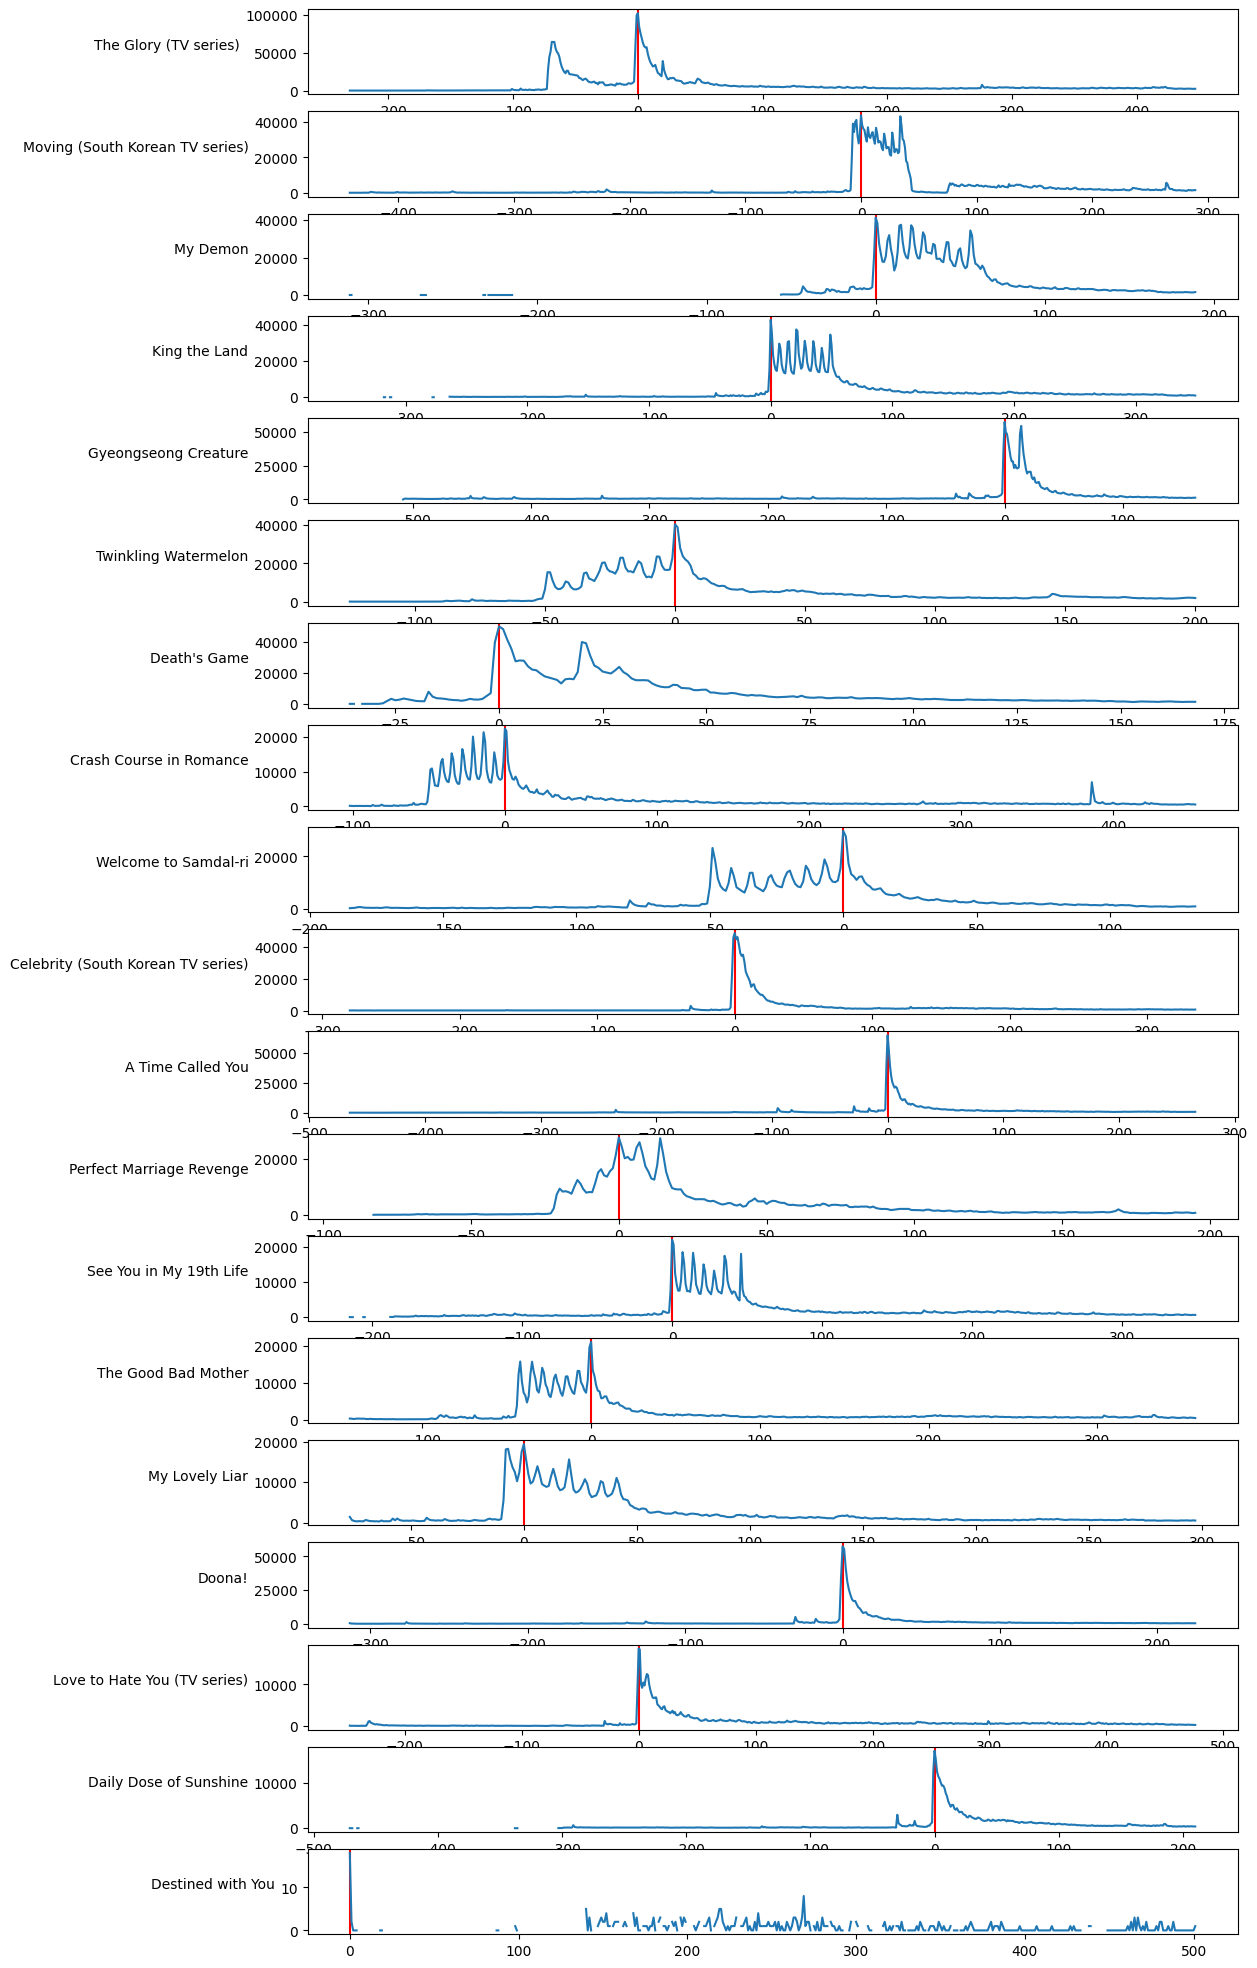

In [28]:
fig, axes = plt.subplots(19,1, figsize=(12,25))
for i, show in enumerate(pageviews.columns):
    ax = axes[i]
    views = pageviews[show]
    days = (views.index - views.idxmax()).days
    ax.axvline(0,color="red")

    ax.plot(days,views)
    ax.set_ylabel(show, rotation=0, ha="right")


axes.set_title("Aligned Pageview Trajectories")
axes.set_xlabel("Days Relative to Peak Date")
plt.show()

